# Red or Green, What Coloured Cat Food does Mi Prefer?

A chi-squared analysis of cat food colour preference. The raw data was recorded by hand on paper data sheets over 30 days (August–September 2024), photographed in `DATA/`, and transcribed into `catfood_summary.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('catfood_summary.csv')
print(df)
print(f'Total days: {df["days_preferred"].sum()}')

  colour  days_preferred
0    red              13
1  green              17
Total days: 30


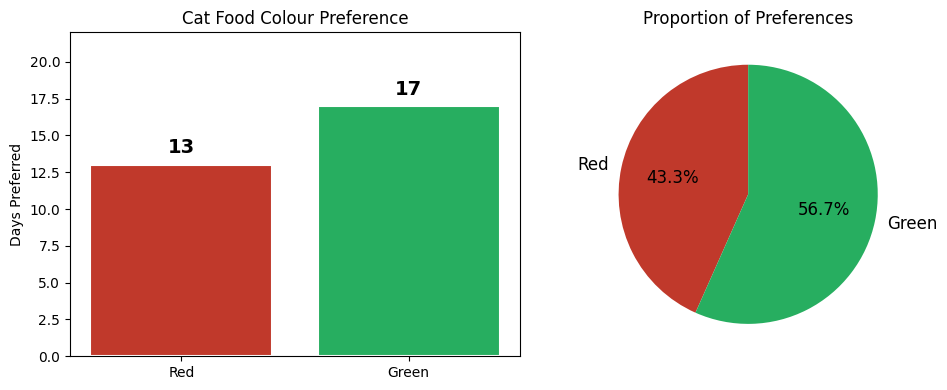

In [2]:
colours = ['#c0392b', '#27ae60']
labels = df['colour'].str.capitalize()
values = df['days_preferred']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
bars = ax1.bar(labels, values, color=colours, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Days Preferred')
ax1.set_title('Cat Food Colour Preference')
ax1.set_ylim(0, max(values) + 5)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=14)
ax2.pie(values, labels=labels, colors=colours, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12})
ax2.set_title('Proportion of Preferences')
plt.tight_layout()
plt.savefig('catfood_preference.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# Chi-squared goodness-of-fit test
# H0: no colour preference (expected 15 each)
# H1: colour preference exists
observed = np.array(values)
expected = np.array([15, 15])

chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)
critical = stats.chi2.ppf(0.95, df=1)

print(f'Observed:   Red={observed[0]}, Green={observed[1]}')
print(f'Expected:   Red={expected[0]}, Green={expected[1]}')
print(f'Chi-squared: {chi2_stat:.3f}')
print(f'p-value:     {p_value:.4f}')
print(f'Critical:    {critical:.3f}')
print(f'\nResult: {chi2_stat:.3f} < {critical:.3f} => fail to reject H0')
print('Mi has no statistically significant colour preference.')

Observed:   Red=13, Green=17
Expected:   Red=15, Green=15
Chi-squared: 0.533
p-value:     0.4652
Critical:    3.841

Result: 0.533 < 3.841 => fail to reject H0
Mi has no statistically significant colour preference.
